In [25]:
from abc import ABC, abstractmethod
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [26]:
class Layer(ABC):
    
    @abstractmethod
    def forward(self, input):
        ...
    
    @abstractmethod
    def backward(self, gradient):
        ...
    
    @abstractmethod
    def update(self, lr):
        ...


In [27]:
class Loss(ABC):
    
    @abstractmethod
    def forward(self, target, preficted):
        ...
    
    @abstractmethod
    def backward(self, target, predicted):
        ...


In [31]:
class MSE(Loss):
    
    @staticmethod
    def forward(target, predicted):
        return np.sum(np.square(predicted - target)) / (target.shape[0] * target.shape[1])
    
    @staticmethod
    def backward(target, predicted):
        return 2 * (predicted - target) / (target.shape[0] * target.shape[1])



In [ ]:
#binary cross-entropy

In [81]:
class BCE(Loss):

    @staticmethod
    def forward(target, predicted):
        predicted = np.clip(predicted, 1e-7, 1 - 1e-7)
        return -1 * (
            target * np.log(predicted)
            + (1 - target) * np.log(1 - predicted)
        )

    @staticmethod
    def backward(target, predicted):
        predicted = np.clip(predicted, 1e-7, 1 - 1e-7)
        return (predicted - target) / (
            predicted * (1 - predicted)
        )
    

In [28]:
class Dense(Layer):
    
    def __init__(self, in_features, out_features):
        super().__init__()
        
        self.in_features = in_features
        self.out_features = out_features
        
        # He initialization
        # self.weights = np.random.randn(in_features, out_features) * np.sqrt(2 / in_features)
        #Xavier
        self.weights = np.random.randn(in_features, out_features) * np.sqrt(2/ (in_features + out_features))
        self.biases = np.zeros(out_features)
    
    def forward(self, input):
        self.input = input
        return input @ self.weights + self.biases
    
    def backward(self, dZ):
        self.dweights = self.input.T @ dZ
        self.dbiases = np.sum(dZ, axis=0)
        return dZ @ self.weights.T
    
    def update(self, lr):
        self.weights -= lr * self.dweights
        self.biases -= lr * self.dbiases


In [60]:
class Sigmoid(Layer):
    
    def forward(self, input):
        self.value = 1 / (1 + np.exp(-1 * input))
        return self.value
    
    def backward(self, dA):
        return dA * (self.value * (1 - self.value))
    
    def update(self, lr):
        pass

In [30]:
class ReLU(Layer):
    
    def forward(self, input):
        self.mask = input > 0
        return np.maximum(0, input)
    
    def backward(self, dA):
        return dA * self.mask
    
    def update(self, lr):
        pass

In [32]:
class Network():
    
    def __init__(self, layers):
        self.layers = layers
    
    def forward(self, X):
        for layer in self.layers:
            X = layer.forward(X)
        return X

    def backward(self, gradient):
        for layer in reversed(self.layers):
            gradient = layer.backward(gradient)

    def update(self, lr):
        for layer in self.layers:
            layer.update(lr)



In [69]:
per = Network(
    [
        Dense(2, 128),
        Sigmoid(),
        Dense(128, 128),
        Sigmoid(),
        Dense(128, 128),
        Sigmoid(),
        Dense(128, 128),
        Sigmoid(),
        Dense(128, 1),
        Sigmoid(),
    ]
)


In [ ]:
#learning

In [70]:
df = pd.read_csv("data.simple.train.1000.csv")

n = 20
epochs = 500

list_df = [df[i:i + n] for i in range(0, df.shape[0], n)]

for epoch in range(epochs):
    for batch in list_df:

        # # changing class to values 0 or 1
        target = (batch.iloc[:, -1:].to_numpy() - 1)

        inputs = batch.iloc[:, :2].to_numpy()

        pred = per.forward(inputs)

        loss = MSE.forward(target, pred)

        gradient = MSE.backward(target, pred)

        per.backward(gradient)

        per.update(0.1)

Loss: 0.008530904350293435
Prediction:
[[5.25563210e-04]
 [5.25512580e-04]
 [5.23990328e-04]
 [9.99937897e-01]
 [9.99999958e-01]
 [9.99999956e-01]
 [9.99999946e-01]
 [5.26357466e-02]
 [9.99999957e-01]
 [5.23922306e-04]
 [5.24686211e-04]
 [5.23943480e-04]
 [5.23984379e-04]
 [5.23903285e-04]
 [9.99999958e-01]
 [9.99999132e-01]
 [5.24090051e-04]
 [9.99999957e-01]
 [5.27172399e-04]
 [5.24725169e-04]]
Predicted classes:
[[1]
 [1]
 [1]
 [2]
 [2]
 [2]
 [2]
 [1]
 [2]
 [1]
 [1]
 [1]
 [1]
 [1]
 [2]
 [2]
 [1]
 [2]
 [1]
 [1]]
Real classes:
[[1]
 [1]
 [1]
 [2]
 [2]
 [2]
 [2]
 [2]
 [2]
 [1]
 [1]
 [1]
 [1]
 [1]
 [2]
 [2]
 [1]
 [2]
 [1]
 [1]]
Accuracy: 0.989


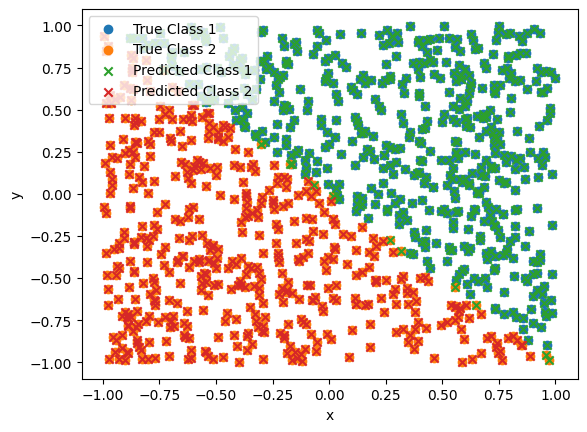

Weights:
[[-2.47319243 -2.09203172  3.81894543 -4.02824419  5.27066794 -0.7645265
   1.92028776 -2.09886741 -1.67990961  0.89893742  2.02405271  0.57292097
   3.6286896   0.8797264  -1.29203564 -1.90474625 -2.39164035  5.12415558
   4.49449367 -2.67665941  0.94589504  0.14159762 -2.16096408  1.2002305
  -1.98911516 -4.31420077 -4.91090967  2.86921249  2.65189726 -5.22322909
   2.36091772  4.62861016  0.0147409   0.82248866  3.65579993 -5.42689336
   1.82047515  2.69129157 -0.15573679 -1.34679753  3.97306696 -1.2307292
  -2.97063149 -2.47158859 -2.14515241 -1.6781579   1.25327394  3.77800284
  -1.48434296 -1.8882238  -1.24914265  0.06413379  2.19389583  1.53996874
  -2.43785415  1.19684573  1.84168227 -1.03481395 -2.56196571  1.11665906
  -0.58116029  3.57320433  4.3823173   3.46489806  3.64124827  0.82336895
   0.30089481 -0.85040331 -0.76345331 -3.2529382   2.03789817 -1.58171456
   1.12560437  0.34584969  0.29841022 -2.80364104  0.60269841 -0.85290512
   0.31606416  0.34417292 -2.262

In [82]:
per = Network(
    [
        Dense(2, 128),
        Sigmoid(),
        Dense(128, 128),
        Sigmoid(),
        Dense(128, 128),
        Sigmoid(),
        Dense(128, 128),
        Sigmoid(),
        Dense(128, 1),
        Sigmoid(),
    ]
)

df = pd.read_csv("data.simple.test.1000.csv")

n = 20
epochs = 500

list_df = [df[i:i + n] for i in range(0, df.shape[0], n)]

for epoch in range(epochs):
    for batch in list_df:

        # # changing class to values 0 or 1
        target = (batch.iloc[:, -1:].to_numpy() - 1)

        inputs = batch.iloc[:, :2].to_numpy()

        pred = per.forward(inputs)

        #loss = MSE.forward(target, pred)

        #gradient = MSE.backward(target, pred)

        loss = BCE.forward(target, pred)

        gradient = BCE.backward(target, pred)

        per.backward(gradient)

        per.update(0.1)


df = pd.read_csv("data.simple.test.1000.csv")

inputs = df.iloc[:, :2].to_numpy()

target = df.iloc[:, -1:].to_numpy()

# changing class to values 0 or 1
target_binary = target - 1


pred = per.forward(inputs)

loss = MSE.forward(target_binary, pred)

pred_class = np.where(pred >= 0.5, 2, 1)


print("Loss:", loss)
print("Prediction:")
print(pred[:20])

print("Predicted classes:")
print(pred_class[:20])

print("Real classes:")
print(target[:20])

accuracy = np.mean(pred_class == target)
print("Accuracy:", accuracy)


x = df.iloc[:, 0].to_numpy()
y = df.iloc[:, 1].to_numpy()


plt.scatter(
    x[target[:, 0] == 1],
    y[target[:, 0] == 1],
    label="True Class 1"
)

plt.scatter(
    x[target[:, 0] == 2],
    y[target[:, 0] == 2],
    label="True Class 2"
)


plt.scatter(
    x[pred_class[:, 0] == 1],
    y[pred_class[:, 0] == 1],
    marker="x",
    label="Predicted Class 1"
)


plt.scatter(
    x[pred_class[:, 0] == 2],
    y[pred_class[:, 0] == 2],
    marker="x",
    label="Predicted Class 2"
)


plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()


print("Weights:")
print(per.layers[0].weights)

print("Biases:")
print(per.layers[0].biases)